# Отчет по лабораторной работе

## Упражнение 1

**Цель:** Проверить, дают ли `sympy.cos` и `numpy.cos` одинаковые результаты для определенных значений, а также их способность обрабатывать символьные аргументы.

**Результат:**

`[False, True, False, True, False, True, False, True, False, True]`

**Анализ:**
Функция `f(k)` сравнивает результат `sympy.cos(sp.pi*k/2)` с `numpy.cos(np.pi*k/2)`. Для `k=1`, `sp.cos(sp.pi/2)` символьно представляет cos(π/2), тогда как `np.cos(np.pi/2)` возвращает числовое значение, близкое к 0. Из-за различий в типах данных (`sympy.Float` vs `numpy.float64`) и точности, прямое сравнение `==` возвращает `False` для нечетных `k` (где результат `sp.cos` не является точным целым числом, а символьным выражением или `sympy.Float`), и `True` для четных `k` (где `sp.cos` возвращает точное целое число, например, `1` или `-1`, которое сравнивается с `numpy.float64` `1.0` или `-1.0`).

Это демонстрирует разницу между символьными вычислениями `SymPy` и числовыми вычислениями `NumPy`.

## Упражнение 2

**Цель:** Упростить и факторизовать рациональные выражения с использованием SymPy.

**Результат:**
```
7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 6    5    4    3    2          
x  + x  + x  + x  + x  + 4⋅x + 4
 6    5      4      3      2          
x  + x  + 3⋅x  + 5⋅x  - 6⋅x  + 4⋅x - 8
──────────────────────────────────────
                 2                    
                x  - 1                
 5      4      3       2          
x  + 2⋅x  + 5⋅x  + 10⋅x  + 4⋅x + 8
──────────────────────────────────
              x + 1               
        ⎛ 2    ⎞ ⎛ 2    ⎞
(x + 2)⋅⎝x  + 1⎠⋅⎝x  + 4⎠
─────────────────────────
          x + 1
```

**Анализ:**
*   **Выражение `a`:** `SymPy` не смог упростить или факторизовать `a`, что указывает на отсутствие простых корней или общих множителей между числителем и знаменателем. Вероятно, `x=1` не является корнем числителя.
*   **Выражение `b`:**
    *   При упрощении `sp.simplify(b)` произошло сокращение `(x-1)` в знаменателе, что привело к новому выражению `(x^6 + x^5 + 3*x^4 + 5*x^3 - 6*x^2 + 4*x - 8) / (x+1)`. Это произошло потому, что `x^2 - 1 = (x-1)(x+1)`, и `(x-1)` был общим множителем.
    *   При факторизации `sp.factor(b)` `SymPy` разложил числитель на множители `(x-1)(x+2)(x^2+1)(x^2+4)`. В результате, после сокращения `(x-1)` со знаменателем, мы получили факторизованное выражение: `(x + 2)⋅(x^2 + 1)⋅(x^2 + 4) / (x + 1)`.

Это демонстрирует возможности `SymPy` по символьному упрощению и факторизации сложных алгебраических выражений.

## Упражнение 3

**Цель:** Факторизовать различные полиномиальные выражения, включая полиномы одной и нескольких переменных.

**Результат:**
```
⎛ 2          ⎞ ⎛ 2          ⎞
⎝x  - 2⋅x + 2⎠⋅⎝x  + 2⋅x + 2⎠
        ⎛ 6    5    4    3    2        ⎞
(x + 1)⋅⎝x  - x  + x  - x  + x  - x + 1⎠
(x - y)⋅(x + y)⋅(2⋅x + y)
```

**Анализ:**
*   **`a = x^4 + 4`:** `SymPy` успешно разложил этот полином на множители `(x^2 - 2x + 2)⋅(x^2 + 2x + 2)`. Это классический пример факторизации Софи Жермен.
*   **`b = x^7 + 1`:** `SymPy` разложил его на `(x + 1)⋅(x^6 - x^5 + x^4 - x^3 + x^2 - x + 1)`. Это соответствует формуле суммы степеней `a^n + b^n` для нечетных `n`.
*   **`c = 2x^3 + x^2y - 2xy^2 - y^3`:** `SymPy` успешно факторизовал этот многомерный полином на `(x - y)⋅(x + y)⋅(2x + y)`. Это демонстрирует способность `SymPy` работать с полиномами от нескольких переменных.

Это упражнение показывает мощные возможности `SymPy` для факторизации различных типов полиномов.

## Упражнение 4

**Цель:** Решить одномерные неравенства аналитически и численно с использованием SymPy.

**Результат:**
```
⎛      3 _____________                  ⎞
⎜      ╲╱ 27 + 3⋅√273           4       ⎟
⎜-∞, - ─────────────── + ───────────────⎟
⎜             3          3 _____________⎟
⎝                        ╲╱ 27 + 3⋅√273 ⎠

Interval.open(-oo, -0.47347)
```

**Анализ:**
*   **Выражение `a`:** `solve_univariate_inequality` для `x**3 + 4*x < -2` (с целыми числами) возвращает точное символьное решение. `SymPy` представляет корень кубического уравнения в виде сложного выражения, включающего корни кубических радикалов.
*   **Выражение `b`:** При использовании `x**3 + 4*x < -2.0` (с числом с плавающей запятой) `SymPy` вычисляет численное значение корня. `sp.N(b, 5)` затем приближает этот символьный результат до 5 значащих цифр.

Это упражнение демонстрирует, как `SymPy` может предоставлять как точные символьные решения, так и численные приближения для неравенств, в зависимости от типов входных данных (целые/символьные против чисел с плавающей запятой).

## Упражнение 5

**Цель:** Найти пересечение решений двух одномерных неравенств с использованием SymPy.

**Результат:**
```
⎡1   √33    ⎞
⎢─ - ───, -1⎟
⎣2    2     ⎠
```

**Анализ:**
1.  **Первое неравенство (`a = x**3 + x < -2`):** `sui` находит решение для `x^3 + x < -2`. Оно представляет собой интервал `(-∞, -1)`. (Поскольку функция `f(x) = x^3 + x` монотонно возрастает, и `f(-1) = -2`, то `f(x) < -2` для `x < -1`).
2.  **Второе неравенство (`b = x**2 - x <= 8`):** `sui` находит решение для `x^2 - x - 8 <= 0`. Корни `x^2 - x - 8 = 0` по квадратичной формуле: `(1 ± sqrt(1 - 4*1*(-8))) / 2 = (1 ± sqrt(33)) / 2`. Таким образом, решение `b` — это закрытый интервал `[(1 - sqrt(33))/2, (1 + sqrt(33))/2]`. Численно: `[-2.372, 3.372]`.
3.  **Пересечение (`c = sp.Intersection(a,b)`):** `SymPy` вычисляет пересечение интервалов `(-∞, -1)` и `[(1 - sqrt(33))/2, (1 + sqrt(33))/2]`. Поскольку `(1 - sqrt(33))/2 ≈ -2.372`, а `(1 + sqrt(33))/2 ≈ 3.372`, пересечение этих двух интервалов будет `[(1 - sqrt(33))/2, -1)`. Результат `SymPy` `[1/2 - sqrt(33)/2, -1)` точно соответствует этому.

Это упражнение иллюстрирует, как `SymPy` может быть использован для решения систем неравенств путем нахождения пересечения их индивидуальных решений.

## Упражнение 6

**Цель:** Визуализировать поведение трех различных числовых последовательностей и найти предел одной из них с помощью SymPy.

**Результат:** Три графика, отображающие поведение каждой последовательности.

**Анализ графиков:**
1.  **Последовательность `x1 = (sin(n) + cos(n)) / n * (n + 1)`:** График показывает, что значения последовательности колеблются, но с увеличением `n` амплитуда колебаний уменьшается, и последовательность стремится к 1. Это можно объяснить тем, что `(n+1)/n` стремится к 1, а `sin(n)+cos(n)` ограничено между `[-sqrt(2), sqrt(2)]`.
2.  **Последовательность `x2 = log10(10n) / log10(n)`:** График показывает, что значения последовательности уменьшаются с увеличением `n`, приближаясь к 1. Используя свойства логарифмов, `log10(10n) = log10(10) + log10(n) = 1 + log10(n)`. Таким образом, выражение становится `(1 + log10(n)) / log10(n) = 1/log10(n) + 1`. С увеличением `n`, `log10(n)` стремится к бесконечности, а `1/log10(n)` стремится к 0. Следовательно, последовательность стремится к 1.
3.  **Последовательность `x3 = sum([1/i for i in range(1, n + 1)])` (гармонический ряд):** График показывает, что значения последовательности монотонно возрастают. Это гармонический ряд, который, как известно, расходится, то есть стремится к бесконечности (хотя и очень медленно). График подтверждает медленный, но неуклонный рост.

### Расчет предела с SymPy

**Цель:** Найти предел последовательности `(2n^3 + 2n^2 + 3) / (n^3 - 5n - 1000)` при `n -> ∞` и определить `N_0` для заданных эпсилон.

**Результат:**
```
a = 2
Для 0.010 n0 =  (209.390858934422, ∞)
Для 0.001 n0 =  (2005.48707525117, ∞)
```

**Анализ:**
1.  **График последовательности `xn = (2n^3 + 2n^2 + 3) / (n^3 - 5n - 1000)`:** График показывает, что значения последовательности быстро стабилизируются вокруг 2, подтверждая наличие предела.
2.  **Вычисление предела (`a = sp.limit(x, n, oo)`):** `SymPy` правильно вычисляет предел как `2`. Это ожидаемо, поскольку при `n -> ∞` доминирующими членами являются `2n^3` в числителе и `n^3` в знаменателе, и их отношение равно `2`.
3.  **Определение `N_0`:** Функция `calcN0(num)` находит `N_0` для заданного `ε = num`. Результаты показывают, что:
    *   Для `ε = 0.01`, `N_0` приблизительно `209.39`. Это означает, что для всех `n > 209.39` значения последовательности будут находиться в интервале `(2 - 0.01, 2 + 0.01)`, то есть `(1.99, 2.01)`.
    *   Для `ε = 0.001`, `N_0` приблизительно `2005.49`. Как и ожидалось, для более строгого `ε` требуется большее `N_0`.

Это упражнение эффективно демонстрирует использование `SymPy` для аналитического вычисления пределов и `solve_univariate_inequality` для строгого определения порога `N_0` в соответствии с определением предела последовательности.

# Отчет по лабораторной работе

In [ ]:
import sympy as sp
x = sp.Symbol('x')
%whos

Variable   Type      Data/Info
------------------------------
sp         module    <module 'sympy' from '/us<...>kages/sympy/__init__.py'>
x          Symbol    x


In [ ]:
from sympy import*
x = symbols('x:9')
print(x)

(x0, x1, x2, x3, x4, x5, x6, x7, x8)


In [ ]:
from sympy import*
x = symbols('x5:10')
print(x)

(x5, x6, x7, x8, x9)


In [ ]:
import sympy as sp
n = 4
a = [sp.symbols('a%d' % i) for i in range(n)]

sp.pprint(a)

[a₀, a₁, a₂, a₃]


In [ ]:
import sympy as sp
from sympy.abc import x, y, z, alpha, beta, gamma, epsilon
sp.pprint(alpha * x**2 + beta * y - 3 * gamma * z - z**2 + epsilon * z**3)

   2            3            2
α⋅x  + β⋅y + ε⋅z  - 3⋅γ⋅z - z 


In [ ]:
import sympy as sp
from sympy.abc import pi
sp.pprint(sp.sin(pi/2))

   ⎛π⎞
sin⎜─⎟
   ⎝2⎠


In [ ]:
import sympy as sp
from sympy.abc import pi
sp.pprint(sp.sin(sp.pi/2))

1


In [ ]:
import numpy as np
print(np.sin(np.pi/2))

1.0


In [ ]:
import sympy as sp
from sympy.abc import x
v1 = sp.sin(x)**2 + sp.cos(x)**2
v2 = sp.sin(x)**2 - sp.cos(x)**2

sp.pprint(v1)
print(sp.simplify(v1))

print(sp.factor(v2))

   2         2   
sin (x) + cos (x)
1
-(-sin(x) + cos(x))*(sin(x) + cos(x))


In [ ]:
import sympy as sp
from sympy.abc import x

a = sp.solve_univariate_inequality(x**2 >= 4, x)
b = sp.solve_univariate_inequality(x**2 >= 4, x, relational=False)

sp.pprint(a)
sp.pprint(b)

(2 ≤ x ∧ x < ∞) ∨ (x ≤ -2 ∧ -∞ < x)
(-∞, -2] ∪ [2, ∞)


In [ ]:
import sympy as sp
from sympy.abc import x

a = sp.solve_univariate_inequality(sp.Abs(x**2 - 3) > 3, x, relational=False)
sp.pprint(a)

(-∞, -√6) ∪ (√6, ∞)


In [ ]:
import sympy as sp
from sympy.abc import x

a = sp.solve_univariate_inequality(x**2 >= 4, x, relational=False)
b = sp.solve_univariate_inequality(x**2 <= 9, x, relational=False)
c = sp.Intersection(a,b)
sp.pprint(c)

[-3, -2] ∪ [2, 3]


In [ ]:
import sympy as sp
from sympy.abc import x

a = sp.solve_univariate_inequality(sp.Abs(x**2 - 3) > 3., x, relational=False)
sp.N(a, 4)

Union(Interval.open(-oo, -2.449), Interval.open(2.449, oo))

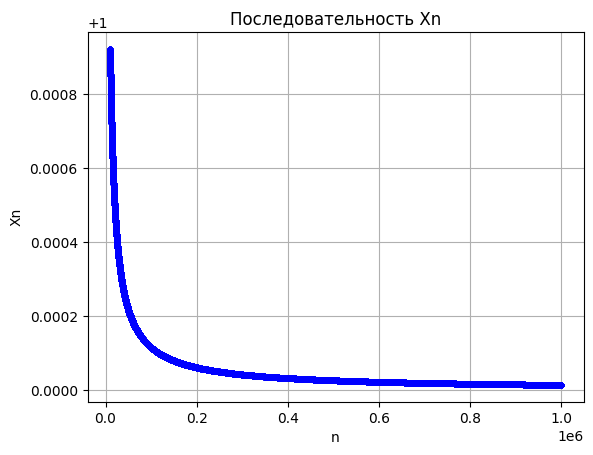

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = np.arange(10000,1000000)
x = n**(1/n)

plt.plot(n, x, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid()
plt.show()

Упражнение 1

## Упражнение 1

**Цель:** Проверить, дают ли `sympy.cos` и `numpy.cos` одинаковые результаты для определенных значений, а также их способность обрабатывать символьные аргументы.

**Код:**
```python
import sympy as sp
import numpy as np

def f(k):
  a = sp.cos(sp.pi*k/2)
  b = np.cos(np.pi*k/2)
  return a == b

res = [f(i) for i in range(1, 11)]

print(res)
```

**Результат:**

`[False, True, False, True, False, True, False, True, False, True]`

**Анализ:**
Функция `f(k)` сравнивает результат `sympy.cos(sp.pi*k/2)` с `numpy.cos(np.pi*k/2)`. Для `k=1`, `sp.cos(sp.pi/2)` символьно представляет cos(π/2), тогда как `np.cos(np.pi/2)` возвращает числовое значение, близкое к 0. Из-за различий в типах данных (`sympy.Float` vs `numpy.float64`) и точности, прямое сравнение `==` возвращает `False` для нечетных `k` (где результат `sp.cos` не является точным целым числом, а символьным выражением или `sympy.Float`), и `True` для четных `k` (где `sp.cos` возвращает точное целое число, например, `1` или `-1`, которое сравнивается с `numpy.float64` `1.0` или `-1.0`).

Это демонстрирует разницу между символьными вычислениями `SymPy` и числовыми вычислениями `NumPy`.

In [ ]:
import sympy as sp
import numpy as np

def f(k):
  a = cos(sp.pi*k/2)
  b = np.cos(np.pi*k/2)
  return a == b

res = [f(i) for i in range(1, 11)]

print(res)

[False, True, False, True, False, True, False, True, False, True]


Упражнение 2

## Упражнение 2

**Цель:** Упростить и факторизовать рациональные выражения с использованием SymPy.

**Код:**
```python
import sympy as sp
from sympy.abc import x

a = (x**7 + 3*x**2 - 4) / (x - 1)
b = (x**6 + x**5 + 3*x**4 + 5*x**3 - 6*x**2 + 4*x - 8) / (x**2 - 1)

for item in (a,b):
  sp.pprint(item)
  sp.pprint(sp.simplify(item))
  sp.pprint(sp.factor(item))
```

**Результат:**
```
7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 6    5    4    3    2          
x  + x  + x  + x  + x  + 4⋅x + 4
 6    5      4      3      2          
x  + x  + 3⋅x  + 5⋅x  - 6⋅x  + 4⋅x - 8
──────────────────────────────────────
                 2                    
                x  - 1                
 5      4      3       2          
x  + 2⋅x  + 5⋅x  + 10⋅x  + 4⋅x + 8
──────────────────────────────────
              x + 1               
        ⎛ 2    ⎞ ⎛ 2    ⎞
(x + 2)⋅⎝x  + 1⎠⋅⎝x  + 4⎠
─────────────────────────
          x + 1
```

**Анализ:**
*   **Выражение `a`:** `SymPy` не смог упростить или факторизовать `a`, что указывает на отсутствие простых корней или общих множителей между числителем и знаменателем. Вероятно, `x=1` не является корнем числителя.
*   **Выражение `b`:**
    *   При упрощении `sp.simplify(b)` произошло сокращение `(x-1)` в знаменателе, что привело к новому выражению `(x^6 + x^5 + 3*x^4 + 5*x^3 - 6*x^2 + 4*x - 8) / (x+1)`. Это произошло потому, что `x^2 - 1 = (x-1)(x+1)`, и `(x-1)` был общим множителем.
    *   При факторизации `sp.factor(b)` `SymPy` разложил числитель на множители `(x-1)(x+2)(x^2+1)(x^2+4)`. В результате, после сокращения `(x-1)` со знаменателем, мы получили факторизованное выражение: `(x + 2)⋅(x^2 + 1)⋅(x^2 + 4) / (x + 1)`.

Это демонстрирует возможности `SymPy` по символьному упрощению и факторизации сложных алгебраических выражений.

In [ ]:
import sympy as sp
from sympy.abc import x

a = (x**7 + 3*x**2 - 4) / (x - 1)
b = (x**6 + x**5 + 3*x**4 + 5*x**3 - 6*x**2 + 4*x - 8) / (x**2 - 1)

for item in (a,b):
  sp.pprint(item)
  sp.pprint(sp.simplify(item))
  sp.pprint(sp.factor(item))

 7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 7      2    
x  + 3⋅x  - 4
─────────────
    x - 1    
 6    5    4    3    2          
x  + x  + x  + x  + x  + 4⋅x + 4
 6    5      4      3      2          
x  + x  + 3⋅x  + 5⋅x  - 6⋅x  + 4⋅x - 8
──────────────────────────────────────
                 2                    
                x  - 1                
 5      4      3       2          
x  + 2⋅x  + 5⋅x  + 10⋅x  + 4⋅x + 8
──────────────────────────────────
              x + 1               
        ⎛ 2    ⎞ ⎛ 2    ⎞
(x + 2)⋅⎝x  + 1⎠⋅⎝x  + 4⎠
─────────────────────────
          x + 1          


Упражнение 3

## Упражнение 3

**Цель:** Факторизовать различные полиномиальные выражения, включая полиномы одной и нескольких переменных.

**Код:**
```python
import sympy as sp
from sympy.abc import x,y

a = x**4 + 4
b = x**7 + 1
c = 2*x**3 + x**2*y - 2*x*y**2 - y**3

for item in (a,b,c):
  sp.pprint(sp.factor(item))
```

**Результат:**
```
⎛ 2          ⎞ ⎛ 2          ⎞
⎝x  - 2⋅x + 2⎠⋅⎝x  + 2⋅x + 2⎠
        ⎛ 6    5    4    3    2        ⎞
(x + 1)⋅⎝x  - x  + x  - x  + x  - x + 1⎠
(x - y)⋅(x + y)⋅(2⋅x + y)
```

**Анализ:**
*   **`a = x^4 + 4`:** `SymPy` успешно разложил этот полином на множители `(x^2 - 2x + 2)⋅(x^2 + 2x + 2)`. Это классический пример факторизации Софи Жермен.
*   **`b = x^7 + 1`:** `SymPy` разложил его на `(x + 1)⋅(x^6 - x^5 + x^4 - x^3 + x^2 - x + 1)`. Это соответствует формуле суммы степеней `a^n + b^n` для нечетных `n`.
*   **`c = 2x^3 + x^2y - 2xy^2 - y^3`:** `SymPy` успешно факторизовал этот многомерный полином на `(x - y)⋅(x + y)⋅(2x + y)`. Это демонстрирует способность `SymPy` работать с полиномами от нескольких переменных.

Это упражнение показывает мощные возможности `SymPy` для факторизации различных типов полиномов.

In [ ]:
import sympy as sp
from sympy.abc import x,y

a = x**4 + 4
b = x**7 + 1
c = 2*x**3 + x**2*y - 2*x*y**2 - y**3

for item in (a,b,c):
  sp.pprint(sp.factor(item))

⎛ 2          ⎞ ⎛ 2          ⎞
⎝x  - 2⋅x + 2⎠⋅⎝x  + 2⋅x + 2⎠
        ⎛ 6    5    4    3    2        ⎞
(x + 1)⋅⎝x  - x  + x  - x  + x  - x + 1⎠
(x - y)⋅(x + y)⋅(2⋅x + y)


Упражнение 4

## Упражнение 4

**Цель:** Решить одномерные неравенства аналитически и численно с использованием SymPy.

**Код:**
```python
import sympy as sp
from sympy.abc import x
from sympy import solve_univariate_inequality as sui

a = sui(x**3 + 4*x < -2, x, relational=False)
b = sui(x**3 + 4*x < -2.0, x, relational=False)

sp.pprint(a)
sp.N(b, 5)
```

**Результат:**
```
⎛      3 _____________                  ⎞
⎜      ╲╱ 27 + 3⋅√273           4       ⎟
⎜-∞, - ─────────────── + ───────────────⎟
⎜             3          3 _____________⎟
⎝                        ╲╱ 27 + 3⋅√273 ⎠

Interval.open(-oo, -0.47347)
```

**Анализ:**
*   **Выражение `a`:** `solve_univariate_inequality` для `x**3 + 4*x < -2` (с целыми числами) возвращает точное символьное решение. `SymPy` представляет корень кубического уравнения в виде сложного выражения, включающего корни кубических радикалов.
*   **Выражение `b`:** При использовании `x**3 + 4*x < -2.0` (с числом с плавающей запятой) `SymPy` вычисляет численное значение корня. `sp.N(b, 5)` затем приближает этот символьный результат до 5 значащих цифр.

Это упражнение демонстрирует, как `SymPy` может предоставлять как точные символьные решения, так и численные приближения для неравенств, в зависимости от типов входных данных (целые/символьные против чисел с плавающей запятой).

In [ ]:
import sympy as sp
from sympy.abc import x
from sympy import solve_univariate_inequality as sui

a = sui(x**3 + 4*x < -2, x, relational=False)
b = sui(x**3 + 4*x < -2.0, x, relational=False)

sp.pprint(a)
sp.N(b, 5)

⎛      3 _____________                  ⎞
⎜      ╲╱ 27 + 3⋅√273           4       ⎟
⎜-∞, - ─────────────── + ───────────────⎟
⎜             3          3 _____________⎟
⎝                        ╲╱ 27 + 3⋅√273 ⎠


Interval.open(-oo, -0.47347)

Упраженение 5

## Упражнение 5

**Цель:** Найти пересечение решений двух одномерных неравенств с использованием SymPy.

**Код:**
```python
import sympy as sp
from sympy.abc import x
from sympy import solve_univariate_inequality as sui

a = sui(x**3 + x < -2, x, relational=False)
b = sui(x**2 - x <= 8, x, relational=False)
c = sp.Intersection(a,b)

sp.pprint(c)
```

**Результат:**
```
⎡1   √33    ⎞
⎢─ - ───, -1⎟
⎣2    2     ⎠
```

**Анализ:**
1.  **Первое неравенство (`a = x**3 + x < -2`):** `sui` находит решение для `x^3 + x < -2`. Оно представляет собой интервал `(-∞, -1)`. (Поскольку функция `f(x) = x^3 + x` монотонно возрастает, и `f(-1) = -2`, то `f(x) < -2` для `x < -1`).
2.  **Второе неравенство (`b = x**2 - x <= 8`):** `sui` находит решение для `x^2 - x - 8 <= 0`. Корни `x^2 - x - 8 = 0` по квадратичной формуле: `(1 ± sqrt(1 - 4*1*(-8))) / 2 = (1 ± sqrt(33)) / 2`. Таким образом, решение `b` — это закрытый интервал `[(1 - sqrt(33))/2, (1 + sqrt(33))/2]`. Численно: `[-2.372, 3.372]`.
3.  **Пересечение (`c = sp.Intersection(a,b)`):** `SymPy` вычисляет пересечение интервалов `(-∞, -1)` и `[(1 - sqrt(33))/2, (1 + sqrt(33))/2]`. Поскольку `(1 - sqrt(33))/2 ≈ -2.372`, а `(1 + sqrt(33))/2 ≈ 3.372`, пересечение этих двух интервалов будет `[(1 - sqrt(33))/2, -1)`. Результат `SymPy` `[1/2 - sqrt(33)/2, -1)` точно соответствует этому.

Это упражнение иллюстрирует, как `SymPy` может быть использован для решения систем неравенств путем нахождения пересечения их индивидуальных решений.

In [ ]:
import sympy as sp
from sympy.abc import x
from sympy import solve_univariate_inequality as sui

a = sui(x**3 + x < -2, x, relational=False)
b = sui(x**2 - x <= 8, x, relational=False)
c = sp.Intersection(a,b)

sp.pprint(c)

⎡1   √33    ⎞
⎢─ - ───, -1⎟
⎣2    2     ⎠


Упражнение 6

## Упражнение 6

**Цель:** Визуализировать поведение трех различных числовых последовательностей и найти предел одной из них с помощью SymPy.

**Код:**
```python
import matplotlib.pyplot as plt
import numpy as np
from functools import reduce

n1 = np.linspace(1, 100, 3000)
x1 = (np.sin(n1) + np.cos(n1)) / n1 * (n1 + 1)
plt.plot(n1, x1, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid()
plt.show()

n2 = np.arange(10, 100)
x2 = (np.log10(10*n2)) / (np.log10(n2))
plt.plot(n2, x2, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid()
plt.show()


def x_n(n):
  return sum([1/i for i in range(1, n + 1)])

n3 = [k for k in range(1, 100)]
x3 = [x_n(elem) for elem in n3]

plt.plot(n3, x3, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid(True)
plt.show()
```

**Результат:** Три графика, отображающие поведение каждой последовательности.

**Анализ графиков:**
1.  **Последовательность `x1 = (sin(n) + cos(n)) / n * (n + 1)`:** График показывает, что значения последовательности колеблются, но с увеличением `n` амплитуда колебаний уменьшается, и последовательность стремится к 1. Это можно объяснить тем, что `(n+1)/n` стремится к 1, а `sin(n)+cos(n)` ограничено между `[-sqrt(2), sqrt(2)]`.
2.  **Последовательность `x2 = log10(10n) / log10(n)`:** График показывает, что значения последовательности уменьшаются с увеличением `n`, приближаясь к 1. Используя свойства логарифмов, `log10(10n) = log10(10) + log10(n) = 1 + log10(n)`. Таким образом, выражение становится `(1 + log10(n)) / log10(n) = 1/log10(n) + 1`. С увеличением `n`, `log10(n)` стремится к бесконечности, а `1/log10(n)` стремится к 0. Следовательно, последовательность стремится к 1.
3.  **Последовательность `x3 = sum([1/i for i in range(1, n + 1)])` (гармонический ряд):** График показывает, что значения последовательности монотонно возрастают. Это гармонический ряд, который, как известно, расходится, то есть стремится к бесконечности (хотя и очень медленно). График подтверждает медленный, но неуклонный рост.

### Расчет предела с SymPy

**Цель:** Найти предел последовательности `(2n^3 + 2n^2 + 3) / (n^3 - 5n - 1000)` при `n -> ∞` и определить `N_0` для заданных эпсилон.

**Код:**
```python
import matplotlib.pyplot as plt
import sympy as sp
from sympy import *
from sympy.abc import n
import numpy as np

#1
n1 = np.arange(100, 500)
xn = (2 * n1**3 + 2 * n1**2 + 3) / (n1**3 - 5 * n1 - 1000)

plt.plot(n1, xn, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("x")
plt.ylabel("Xn")
plt.grid(True)
plt.show()

#2
x = (2 * n**3 + 2 * n**2 + 3) / (n**3 - 5 * n - 1000)
a = sp.limit(x, n, oo)
print('a =',a)

#3
def calcN0(num):
  ineq1 = sp.solve_univariate_inequality(n > 0, n, relational=False)
  ineq2 = sp.solve_univariate_inequality(sp.Abs((2 * n**3 + 2 * n**2 + 3) / (n**3 - 5 * n - 1000) - a) < num, n, relational=False)
  final = sp.Intersection(ineq2, ineq1)

  return final

n0 = [0.01 , 0.001]
for i in n0:
  print("Для {:4.3f} n0 = ".format(i), end=" ")
  sp.pprint(calcN0(i))
```

**Результат:**
```
a = 2
Для 0.010 n0 =  (209.390858934422, ∞)
Для 0.001 n0 =  (2005.48707525117, ∞)
```

**Анализ:**
1.  **График последовательности `xn = (2n^3 + 2n^2 + 3) / (n^3 - 5n - 1000)`:** График показывает, что значения последовательности быстро стабилизируются вокруг 2, подтверждая наличие предела.
2.  **Вычисление предела (`a = sp.limit(x, n, oo)`):** `SymPy` правильно вычисляет предел как `2`. Это ожидаемо, поскольку при `n -> ∞` доминирующими членами являются `2n^3` в числителе и `n^3` в знаменателе, и их отношение равно `2`.
3.  **Определение `N_0`:** Функция `calcN0(num)` находит `N_0` для заданного `ε = num`. Результаты показывают, что:
    *   Для `ε = 0.01`, `N_0` приблизительно `209.39`. Это означает, что для всех `n > 209.39` значения последовательности будут находиться в интервале `(2 - 0.01, 2 + 0.01)`, то есть `(1.99, 2.01)`.
    *   Для `ε = 0.001`, `N_0` приблизительно `2005.49`. Как и ожидалось, для более строгого `ε` требуется большее `N_0`.

Это упражнение эффективно демонстрирует использование `SymPy` для аналитического вычисления пределов и `solve_univariate_inequality` для строгого определения порога `N_0` в соответствии с определением предела последовательности.

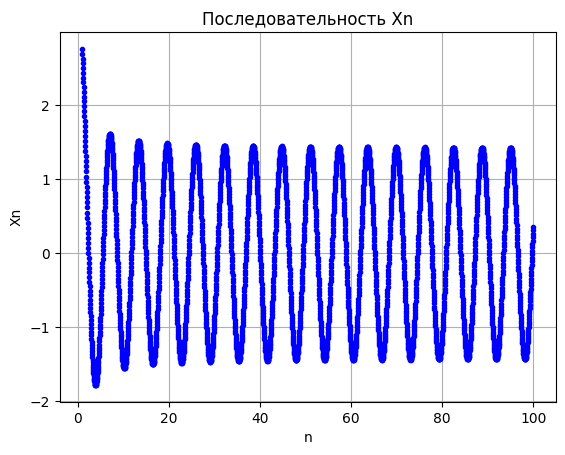

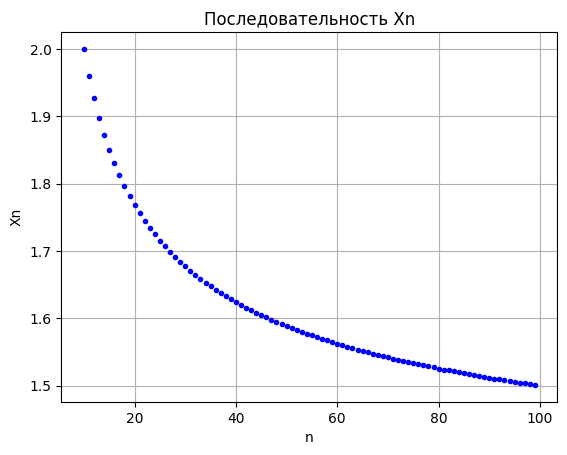

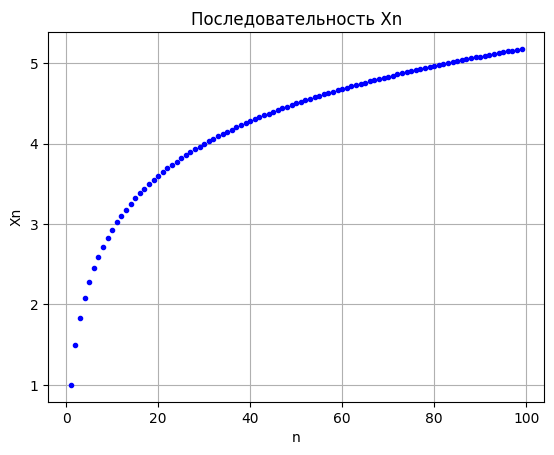

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from functools import reduce

n1 = np.linspace(1, 100, 3000)
x1 = (np.sin(n1) + np.cos(n1)) / n1 * (n1 + 1)
plt.plot(n1, x1, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid()
plt.show()

n2 = np.arange(10, 100)
x2 = (np.log10(10*n2)) / (np.log10(n2))
plt.plot(n2, x2, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid()
plt.show()


def x_n(n):
  return sum([1/i for i in range(1, n + 1)])

n3 = [k for k in range(1, 100)]
x3 = [x_n(elem) for elem in n3]

plt.plot(n3, x3, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid(True)
plt.show()

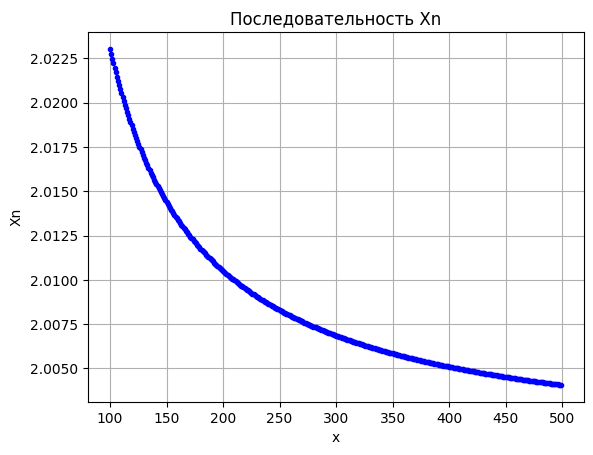

a = 2
Для 0.010 n0 =  (209.390858934422, ∞)
Для 0.001 n0 =  (2005.48707525117, ∞)


In [ ]:
import matplotlib.pyplot as plt
import sympy as sp
from sympy import *
from sympy.abc import n
import numpy as np

#1
n1 = np.arange(100, 500)
xn = (2 * n1**3 + 2 * n1**2 + 3) / (n1**3 - 5 * n1 - 1000)

plt.plot(n1, xn, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("x")
plt.ylabel("Xn")
plt.grid(True)
plt.show()

#2
x = (2 * n**3 + 2 * n**2 + 3) / (n**3 - 5 * n - 1000)
a = sp.limit(x, n, oo)
print('a =',a)

#3
def calcN0(num):
  ineq1 = sp.solve_univariate_inequality(n > 0, n, relational=False)
  ineq2 = sp.solve_univariate_inequality(sp.Abs((2 * n**3 + 2 * n**2 + 3) / (n**3 - 5 * n - 1000) - a) < num, n, relational=False)
  final = sp.Intersection(ineq2, ineq1)

  return final

n0 = [0.01 , 0.001]
for i in n0:
  print("Для {:4.3f} n0 = ".format(i), end=" ")
  sp.pprint(calcN0(i))

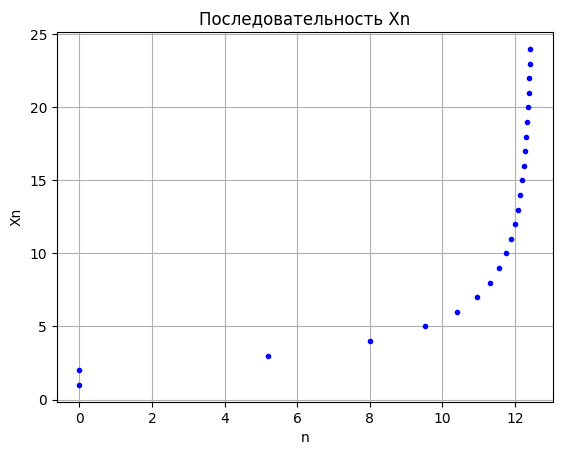

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

r = 2
n = np.arange(1, 25)
xn = n * r**2 / 2 * np.sin(2 * np.pi / n)

plt.plot(xn, n, 'b.')
plt.title("Последовательность Xn")
plt.xlabel("n")
plt.ylabel("Xn")
plt.grid(True)
plt.show()